# Fitting of data by theoretical distributions

## Problem 7-31
Fit a binomial distribution to the data of Problem 2.17

,Number.of.Heads,Number.of.Tosses
,<int>,<int>
1,0,38
2,1,144
3,2,342
4,3,287
5,4,164
6,5,25


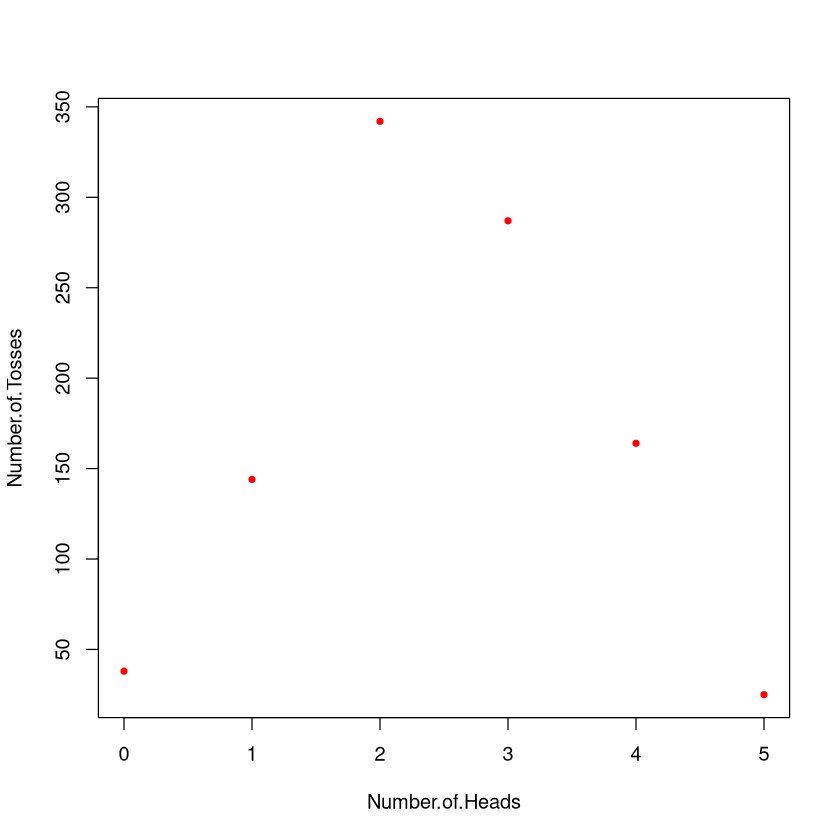

In [1]:
p7.31 <- new.env()
(p7.31$df <- read.table("../../Saves/Table_2.13.Rdata"))
plot(p7.31$df, col="red", pch=20)

### SOLUTION
We have $\text{Pr}\{X \text{ heads in a toss of 5 pennies}\}=p(X)=\binom{5}{X}p^Xq^{5-X}$, where $p$ and $q$ are the respective probabilities of a head and a tail on a single toss of a penny. By Problem 7.11(a), the mean number of heads is $\mu=Np=5p$. For the actual (or observed) frequency distribution, the mean number of heads is
\begin{align}
\frac{\sum{fX}}{\sum{f}}=\frac{(38)(0)+(144)(1) + (342)(2) + (287)(3) + (164)(4) + (25)(5)}{1000}=\frac{2470}{1000}=2.47
\end{align}
Equating the theoretical and actual means, $5p=2.47$, or $p=0.494$. Thus the fitted binomial distribution is givent by
\begin{align}
p(X)=\binom{5}{X}(0.494)^X(0.506)^{5-X}\text{.}
\end{align}

In [2]:
p7.31$N <- 5
p7.31$f <- sum(p7.31$df$Number.of.Tosses)
p7.31$fX <- sum(p7.31$df$Number.of.Heads * p7.31$df$Number.of.Tosses)
(p7.31$mean <- sum(p7.31$fX/p7.31$f))
(p7.31$p <- p7.31$mean / p7.31$N)
p7.31$p.model <- function(X) choose(5, X)*(0.494)^X*(0.506)^(5-X)
(expected <- round(p7.31$p.model(c(0, 1, 2, 3, 4, 5))*p7.31$f,0))
cbind(p7.31$df, expected)
rm(p7.31)

[1] 2.47

[1] 0.494

[1]  33 162 316 309 151  29

,Number.of.Heads,Number.of.Tosses,expected
,<int>,<int>,<dbl>
1,0,38,33
2,1,144,162
3,2,342,316
4,3,287,309
5,4,164,151
6,5,25,29


---

## Problem 7-32
Use the Kolmogorov-Smirnov test to test the data in Table 7.5 for normality. The data represent the time spent on a cell phone per week for 30 college students.

[1] 16 14 12 13 10 13 17 14 11 13 17 14 16 11 15 15 13 18 12 15 15 16 12 14 14
[26] 16 15 14 13 12

ERROR: Error in eval(expr, envir, enclos): object 'x' not found


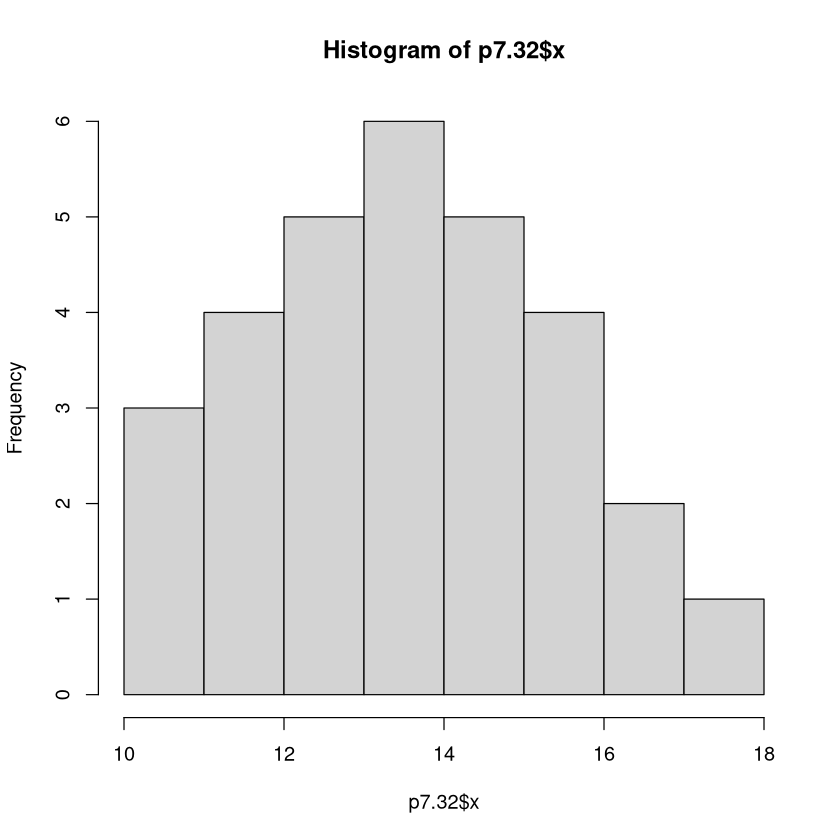

In [3]:
p7.32 <- new.env()
(p7.32$x <- read.table("../../Saves/Table_7.5.Rdata")$x)
hist(p7.32$x)
ks.test(x, "pnorm")
rm(p7.32)

---

## Problem 7-33
Use the Kolmogorov-Smirnov on the data in Table 7.6 for normality. The data represent the time spent on a cell phone per week for 30 college students.

In [ ]:
p7.33 <- new.env()
p7.33$x <- read.table("../../Saves/Table_7.6.Rdata")$x
hist(p7.33$x)
ks.test(p7.33$x,"pnorm")
rm(p7.33)

---

## Problem 7-34
Table 7.7 shows the number of days, $f$, in a 50-day period during which $X$ automobile accidents occurred in a cit. Fit a Poisson distribution to the data.

In [ ]:
p7.34 <- new.env()
p7.34$df <- read.table("../../Saves/Table_7.7.Rdata")

### SOLUTION
The mean number of accidents is
\begin{align}
\lambda = \frac{\sum{fX}}{\sum{f}} = \frac{(21)(0) + (18)(1) + (7)(2) + (3)(3) + (1)(4)}{50} = \frac{45}{50} = 0.90
\end{align}
Thus, according to the Poisson distribution,
\begin{align}
\text{Pr}\{X \text{ accidents}\}=\frac{(0.90)^X e^{-.90}}{X!}
\end{align}

In [ ]:
p7.34$model <- function(X) ((0.90)^X*exp(-.90)) / (factorial(X))
(p7.34$Pr <- choose(c(0,1,2,3,4),50))